# OPTED Reverse Dictionary - Exploratory Data Analysis

Dataset:
- Word
- Count
- POS
- Definition

This notebook covers:

1. Dataset overview
2. Missing value analysis
3. Duplicate and multiple-definition analysis
4. Definition length analysis
5. Vocabulary analysis
6. POS analysis
7. Count column analysis
8. Definitions per word distribution
9. Word length analysis
10. POS consistency investigation
11. EDA visualizations export
12. Final EDA summary


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path
import re

# pd.set_option("display.max_columns", None)
# pd.set_option("display.max_colwidth", 200)

FILE_PATH = Path("../data/OPTED-Dictionary.csv")

WORD_COL = "Word"
COUNT_COL = "Count"
POS_COL = "POS"
DEF_COL = "Definition"

df = pd.read_csv(FILE_PATH)

print(df.shape)
df.head()


(176009, 4)


,Word,Count,POS,Definition
0,A,1,"""""","""The first letter of the English and of many other alphabets. The capital A of the alphabets of Middle and Western Europe as also the small letter (a) besides the forms in Italic black letter etc..."
1,A,1,"""""","""The name of the sixth tone in the model major scale (that in C) or the first tone of the minor scale which is named after it the scale in A minor. The second string of the violin is tuned to the..."
2,A,1,"""""","""An adjective commonly called the indefinite article and signifying one or any but less emphatically."""
3,A,1,"""""","""In each; to or for each; as """"""""twenty leagues a day"""""""" """"""""a hundred pounds a year"""""""" """"""""a dollar a yard"""""""" etc."""
4,A,1,"""prep.""","""In; on; at; by."""


# 1. Dataset Overview

In [26]:
overview = pd.DataFrame({
    "Column": df.columns,
    "Datatype": df.dtypes.astype(str),
    "Non Null": df.notna().sum(),
    "Unique Values": df.nunique()
})

display(overview)

print("Rows:", len(df))
print("Unique words:", df[WORD_COL].nunique())


,Column,Datatype,Non Null,Unique Values
Word,Word,str,176005,111596
Count,Count,float64,175802,27
POS,POS,str,176009,295
Definition,Definition,str,176009,166067
POS_clean,POS_clean,str,176009,295
Count_clean,Count_clean,float64,175802,27
computed_word_length,computed_word_length,Int64,176005,26


Rows: 176009
Unique words: 111596


In [27]:
INVALID_VALUES = [
    "#NAME?",
    "#VALUE!",
    "#REF!",
    "#DIV/0!",
    "N/A",
    "NA",
    "NULL",
    "",
    '""'
]


def is_invalid(value):
    """
    Detect missing or invalid placeholder values
    """

    if pd.isna(value):
        return True

    return str(value).strip() in INVALID_VALUES

# 2. Missing Values

In [28]:
null_summary = df.isna().sum()


invalid_summary = {}

for col in df.columns:
    invalid_summary[col] = (
        df[col]
        .apply(is_invalid)
        .sum()
    )


missing_summary = pd.DataFrame({
    "Null Values": null_summary,
    "Invalid Placeholder Values": pd.Series(invalid_summary)
})


missing_summary["Total Missing/Invalid"] = (
    missing_summary["Null Values"]
    +
    missing_summary["Invalid Placeholder Values"]
)


display(missing_summary)

,Null Values,Invalid Placeholder Values,Total Missing/Invalid
Word,4,211,215
Count,207,207,414
POS,0,3906,3906
Definition,0,2,2
POS_clean,0,3906,3906
Count_clean,207,207,414
computed_word_length,4,4,8


# 3. Duplicate and Multiple Definition Analysis

In [29]:
print("Duplicate rows:", df.duplicated().sum())

print(
    "Duplicate word-definition pairs:",
    df.duplicated([WORD_COL, DEF_COL]).sum()
)

definitions_per_word = (
    df.groupby(WORD_COL)[DEF_COL]
    .nunique()
    .sort_values(ascending=False)
)

multi_definition_words = definitions_per_word[definitions_per_word > 1]

print(
    "Words with multiple definitions:",
    len(multi_definition_words)
)

display(multi_definition_words.head(20))


Duplicate rows: 101
Duplicate word-definition pairs: 247
Words with multiple definitions: 25195


Word
#NAME?    197
Run        71
Set        59
Light      47
Round      46
Cast       45
Line       44
Strike     44
Rise       42
Point      41
Fall       41
Lay        40
Touch      40
Pass       39
Base       39
Turn       38
Break      37
Roll       36
Draw       36
Square     36
Name: Definition, dtype: int64

# 4. Definition Length Analysis

In [30]:
valid_definition_df = df[
    ~df[DEF_COL].apply(is_invalid)
]

valid_definition_df["definition_word_count"] = (
    valid_definition_df[DEF_COL]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

valid_definition_df["definition_char_count"] = (
    valid_definition_df[DEF_COL]
    .fillna("")
    .astype(str)
    .str.len()
)

display(valid_definition_df[[
    "definition_word_count",
    "definition_char_count"
]].describe())


,definition_word_count,definition_char_count
count,176007.000000,176007.000000
mean,11.158386,66.692092
std,10.568538,60.767011
min,1.000000,3.000000
25%,3.000000,23.000000
50%,8.000000,48.000000
75%,15.000000,90.000000
max,148.000000,807.000000


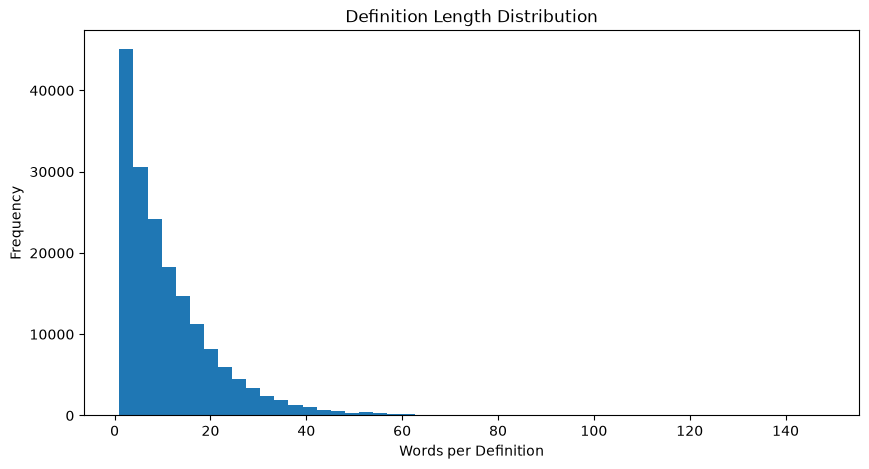

In [31]:
plt.figure(figsize=(10,5))
plt.hist(valid_definition_df["definition_word_count"], bins=50)
plt.title("Definition Length Distribution")
plt.xlabel("Words per Definition")
plt.ylabel("Frequency")
plt.show()


# 5. Vocabulary Analysis

In [32]:
clean_definitions = df[
    ~df[DEF_COL].apply(is_invalid)
][DEF_COL]


all_definition_text = " ".join(
    clean_definitions.astype(str)
)

tokens = re.findall(
    r"\b[a-zA-Z]+\b",
    all_definition_text.lower()
)

counter = Counter(tokens)

print("Total tokens:", len(tokens))
print("Unique tokens:", len(counter))

top_words = pd.DataFrame(
    counter.most_common(20),
    columns=["Word","Frequency"]
)

display(top_words)


Total tokens: 1959826
Unique tokens: 72656


,Word,Frequency
0,of,131548
1,a,114440
2,the,111251
3,to,97431
4,or,88696
5,as,38989
6,in,37961
7,and,26237
8,an,18943
9,by,17799


# 6. POS Analysis

Total unique POS categories: 295


,Count
POS_clean,
"""n.""",84932
"""a.""",35189
"""v. t.""",18216
"""v. i.""",7167
"""p. pr. & vb. n.""",5802
...,...
"""e""",1
"""t""",1
"""Archaic""",1


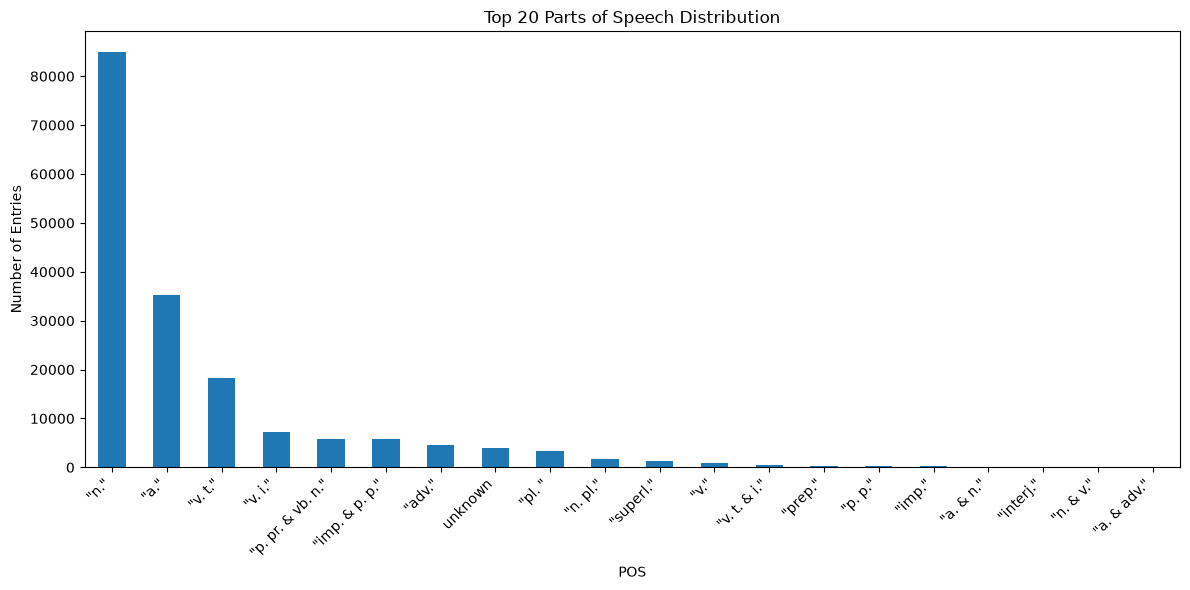

,POS_clean,Percentage
0,"""n.""",48.25
1,"""a.""",19.99
2,"""v. t.""",10.35
3,"""v. i.""",4.07
4,"""p. pr. & vb. n.""",3.30
5,"""imp. & p. p.""",3.29
6,"""adv.""",2.55
7,unknown,2.22
8,"""pl. """,1.95
9,"""n. pl.""",0.97


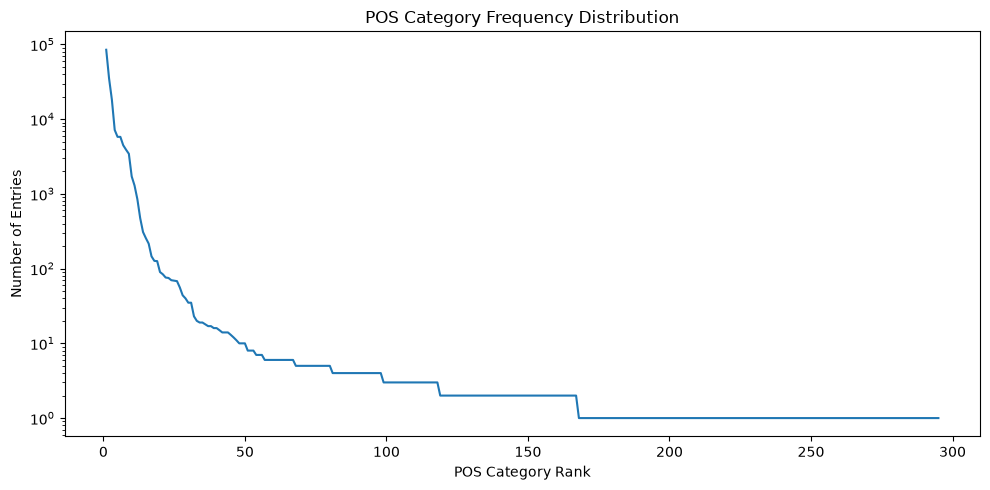

Unique raw POS labels: 295
Unique cleaned POS labels: 295

Top 20 POS labels:


,Count
POS_clean,
"""n.""",84932
"""a.""",35189
"""v. t.""",18216
"""v. i.""",7167
"""p. pr. & vb. n.""",5802
"""imp. & p. p.""",5797
"""adv.""",4481
unknown,3906
"""pl. """,3440



20 rarest POS labels:


,Count
POS_clean,
"""v.impers.""",1
"""syntactically sing.""",1
"""v. impersonal",1
"""definite article.""",1
"""def. art.""",1
"""p. p. &""",1
"""prep. & conj.""",1
"""v. r.""",1
"""comp.""",1


In [33]:
df["POS_clean"] = df[POS_COL].apply(
    lambda x: "unknown" if is_invalid(x) else str(x).strip()
)

pos_distribution = (
    df["POS_clean"]
    .value_counts()
)


print(f"Total unique POS categories: {len(pos_distribution)}")

display(
    pos_distribution
    .to_frame("Count")
)

top_pos = (
    pos_distribution
    .head(20)
)


plt.figure(figsize=(12,6))

top_pos.plot(
    kind="bar"
)

plt.title(
    "Top 20 Parts of Speech Distribution"
)

plt.xlabel("POS")
plt.ylabel("Number of Entries")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

pos_percentage = (
    pos_distribution
    .head(20)
    .div(len(df))
    .mul(100)
    .round(2)
)


pos_percentage_df = (
    pos_percentage
    .rename("Percentage")
    .reset_index()
    .rename(columns={
        "index": "POS"
    })
)


display(pos_percentage_df)

plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(pos_distribution)+1),
    pos_distribution.values
)

plt.title(
    "POS Category Frequency Distribution"
)

plt.xlabel(
    "POS Category Rank"
)

plt.ylabel(
    "Number of Entries"
)

plt.yscale("log")

plt.tight_layout()
plt.show()

# POS label consistency summary

print(f"Unique raw POS labels: {df[POS_COL].nunique(dropna=True)}")
print(f"Unique cleaned POS labels: {df['POS_clean'].nunique()}")

print("\nTop 20 POS labels:")
display(
    df["POS_clean"]
    .value_counts()
    .head(20)
    .rename("Count")
    .to_frame()
)

print("\n20 rarest POS labels:")
display(
    df["POS_clean"]
    .value_counts()
    .tail(20)
    .rename("Count")
    .to_frame()
)

# 7. Count Column Analysis

Provided word-length statistics:


count    175802.000000
mean          7.984278
std           2.739092
min           0.000000
25%           6.000000
50%           8.000000
75%          10.000000
max          83.000000
Name: Count_clean, dtype: float64

,Metric,Count
0,Rows checked,175798
1,Matching lengths,175787
2,Mismatching lengths,11
3,Invalid/missing Count values,207


Rows where Count does not match the computed length:


,Word,Count,Count_clean,computed_word_length
22407,Ca�ada,8.0,8.0,6
22644,Ca�on,7.0,7.0,5
46854,Do�a,6.0,6.0,4
48535,Due�a,7.0,7.0,5
92137,Madro�a,9.0,9.0,7
114602,Pi�a cloth,12.0,12.0,10
114793,Pi�on,7.0,7.0,5
114794,Pi�on,7.0,7.0,5
138381,Se�or,7.0,7.0,5
138382,Se�ora,8.0,8.0,6


,Number of Entries
Count_clean,
0,1
1,67
2,284
3,3937
4,13449
5,17233
6,21576
7,23644
8,23821


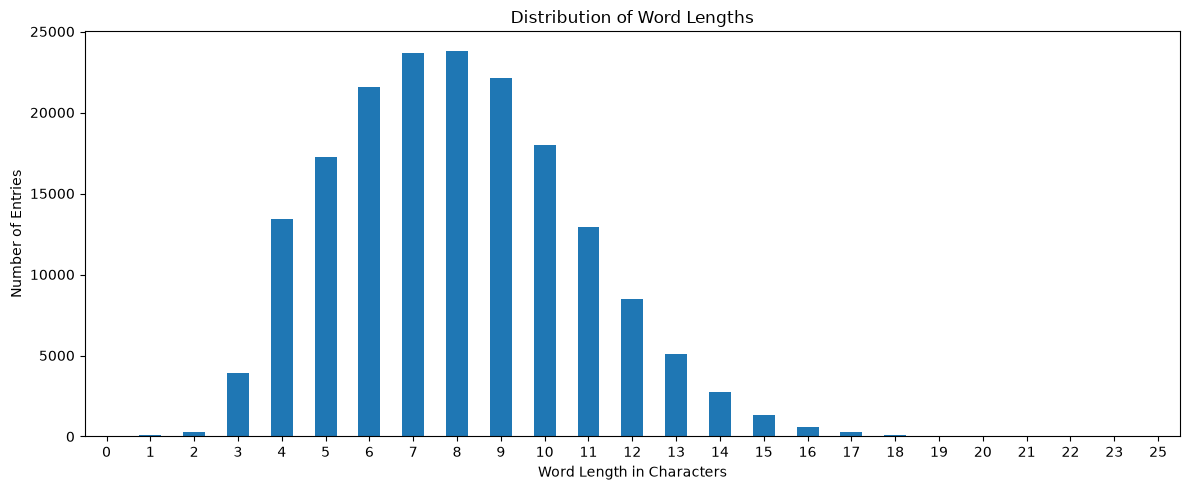

In [34]:
df["Count_clean"] = pd.to_numeric(
    df[COUNT_COL],
    errors="coerce"
)

df["computed_word_length"] = (
    df[WORD_COL]
    .astype("string")
    .str.len()
)

print("Provided word-length statistics:")
display(df["Count_clean"].describe())

valid_length_rows = df[
    df["Count_clean"].notna()
    & df["computed_word_length"].notna()
].copy()

valid_length_rows["length_matches"] = (
    valid_length_rows["Count_clean"]
    == valid_length_rows["computed_word_length"]
)

length_validation_summary = pd.DataFrame({
    "Metric": [
        "Rows checked",
        "Matching lengths",
        "Mismatching lengths",
        "Invalid/missing Count values"
    ],
    "Count": [
        len(valid_length_rows),
        int(valid_length_rows["length_matches"].sum()),
        int((~valid_length_rows["length_matches"]).sum()),
        int(df["Count_clean"].isna().sum())
    ]
})

display(length_validation_summary)

print("Rows where Count does not match the computed length:")

display(
    valid_length_rows.loc[
        ~valid_length_rows["length_matches"],
        [WORD_COL, COUNT_COL, "Count_clean", "computed_word_length"]
    ].head(30)
)

word_length_distribution = (
    df["Count_clean"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

display(
    word_length_distribution
    .rename("Number of Entries")
    .to_frame()
)

plt.figure(figsize=(12, 5))

word_length_distribution.loc[
    word_length_distribution.index <= 25
].plot(kind="bar")

plt.title("Distribution of Word Lengths")
plt.xlabel("Word Length in Characters")
plt.ylabel("Number of Entries")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 8. Definitions per Word Distribution

,Number of Words
Definition,
1,86401
2,13397
3,4818
4,2319
5,1341
6,933
7,567
8,413
9,299


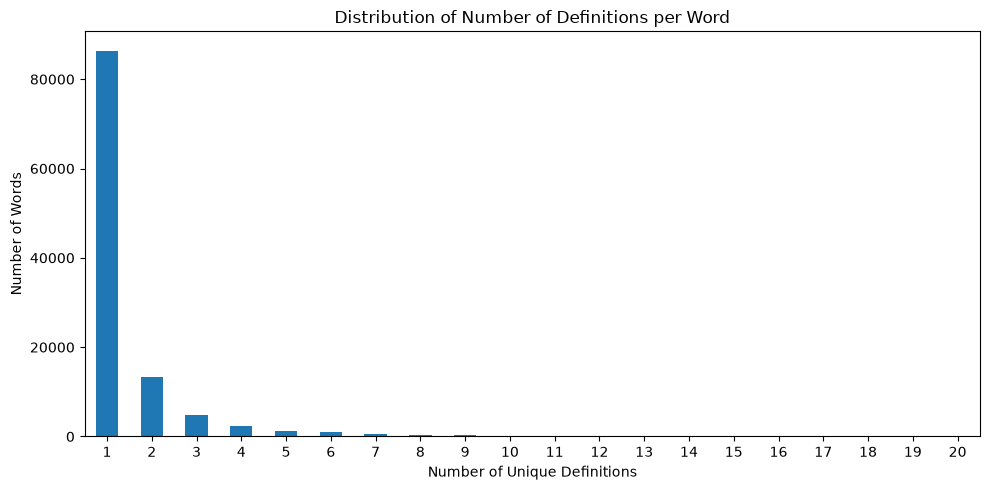

Words with multiple definitions:


,Number of Definitions
Word,
Run,71
Set,59
Light,47
Round,46
Cast,45
Line,44
Strike,44
Rise,42
Fall,41


In [35]:
valid_word_definition_df = df[
    ~df[WORD_COL].apply(is_invalid)
    & ~df[DEF_COL].apply(is_invalid)
].copy()

definitions_per_word = (
    valid_word_definition_df
    .groupby(WORD_COL)[DEF_COL]
    .nunique()
    .sort_values(ascending=False)
)

definitions_frequency = (
    definitions_per_word
    .value_counts()
    .sort_index()
)

display(
    definitions_frequency
    .rename("Number of Words")
    .to_frame()
)

plt.figure(figsize=(10, 5))

definitions_frequency.head(20).plot(
    kind="bar"
)

plt.title("Distribution of Number of Definitions per Word")
plt.xlabel("Number of Unique Definitions")
plt.ylabel("Number of Words")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Words with multiple definitions:")

display(
    definitions_per_word[
        definitions_per_word > 1
    ]
    .head(20)
    .rename("Number of Definitions")
    .to_frame()
)

# 11. EDA Summary

In [36]:
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Unique words",
        "Unique definitions",
        "Words with multiple definitions",
        "Average definition length",
        "Vocabulary size",
        "Unique POS labels"
    ],
    "Value": [
        len(df),
        df[WORD_COL].nunique(),
        df[DEF_COL].nunique(),
        len(multi_definition_words),
        round(valid_definition_df["definition_word_count"].mean(),2),
        len(counter),
        df['POS_clean'].nunique()
    ]
})

display(summary)


,Metric,Value
0,Rows,176009.00
1,Unique words,111596.00
2,Unique definitions,166067.00
3,Words with multiple definitions,25195.00
4,Average definition length,11.16
5,Vocabulary size,72656.00
6,Unique POS labels,295.00


## EDA Findings and Observations

### 1. Dataset composition

The raw OPTED dataset contains **176,009 dictionary entries** with the columns `Word`, `Count`, `POS`, and `Definition`. It contains **111,596 unique word labels** and **166,067 unique definitions** before removing invalid placeholder values.

Each row represents a word-definition pair. Therefore, the same word may occur in multiple rows when it has multiple meanings or grammatical usages.

### 2. Data-quality observations

The dataset contains a small number of missing or invalid values that must be handled during preprocessing.

- The `Word` column contains **4 null values** and **207 `#NAME?` placeholders**.
- The `Count` column contains **207 non-numeric `#NAME?` values**.
- The `POS` column uses `""` to represent an unknown or unavailable part of speech in approximately **3,906 entries**.
- The `Definition` column contains a very small number of empty quoted values.
- There are **101 exact duplicate rows**.
- There are **247 repeated word-definition pairs**.

Invalid words and definitions should be removed before modelling, while missing POS values can be retained using a common label such as `unknown`. Exact duplicate rows should also be removed so that repeated records do not influence the later model or evaluation.

### 3. Interpretation of the `Count` column

The `Count` column represents the **number of characters in the corresponding word or phrase**. It does not represent word frequency or the number of definitions associated with a word.

After converting `Count` to a numeric value, it matched the directly calculated length of the `Word` field for **175,787 out of 175,798 comparable rows**, showing that the column is highly consistent with its intended meaning. The small number of mismatches should be inspected during preprocessing because they may represent malformed or shifted records.

The word-length distribution is concentrated around **6 to 12 characters**, with a median length of approximately **8 characters**. Very short and very long words occur much less frequently.

### 4. Definition-length distribution

Definitions have an average length of approximately **11 words**, while the median is **8 words**. Approximately 75% of definitions contain no more than **15 words**, although a small number of definitions are substantially longer, with the longest containing approximately **148 words**.

The histogram indicates a right-skewed distribution: most definitions are relatively short, while a limited number of long definitions form the upper tail. Some extremely short or punctuation-only definitions were also observed and should be reviewed during preprocessing.

### 5. Words with multiple definitions

After excluding invalid word and definition values, approximately **25,194 words** have more than one unique definition. This represents about **22.6% of the valid unique words**, while approximately **77.4%** have only one definition.

Examples of highly polysemous words include:

- `Run` — 71 unique definitions
- `Set` — 59 unique definitions
- `Light` — 47 unique definitions
- `Round` — 46 unique definitions
- `Cast` — 45 unique definitions

The train, validation, and test split should therefore be performed by **unique word rather than individual row**. Otherwise, one definition of a word could appear in the training set while another definition of the same word appears in the test set, causing data leakage.

### 6. Vocabulary characteristics

The definitions contain approximately **1.96 million tokens** and **72,656 unique alphabetic tokens** before stop-word removal.

The most frequently occurring tokens include `of`, `a`, `the`, `to`, `or`, `as`, `in`, and `and`. Most of these are common English function words. This confirms that stop words occupy a substantial portion of the vocabulary.

However, stop-word removal should be treated as an experimental preprocessing choice rather than assumed to be beneficial. A version with stop words and a version without stop words can later be compared during retrieval evaluation.

### 7. Part-of-speech distribution

The dataset contains **295 raw POS labels**, including standard abbreviations, combined grammatical labels, archaic labels, and formatting variations.

The dominant categories are:

- Noun (`n.`): approximately **48.25%**
- Adjective (`a.`): approximately **19.99%**
- Transitive verb (`v. t.`): approximately **10.35%**
- Intransitive verb (`v. i.`): approximately **4.07%**
- Participial or verbal-noun forms (`p. pr. & vb. n.`): approximately **3.30%**
- Adverb (`adv.`): approximately **2.55%**
- Unknown or empty POS: approximately **2.22%**

The POS-frequency chart shows a strong long-tail distribution. A small number of POS labels account for most entries, while many labels occur only a few times. During preprocessing, formatting artifacts and empty values should be normalized. Mapping all detailed labels into broad categories such as noun, verb, adjective, and adverb may be considered separately if POS is later used as a model feature.

### 8. Overall EDA conclusion

The OPTED dataset is sufficiently large and contains broad lexical coverage, but it also includes duplicate records, spreadsheet error placeholders, empty POS values, highly polysemous words, and a small number of malformed entries.

Based on the EDA, the preprocessing stage should:

1. Preserve the original raw CSV without modification.
2. Remove rows with invalid words or unusable definitions.
3. Convert `Count` to numeric word length and inspect mismatches.
4. Normalize whitespace, quotation artifacts, and missing POS values.
5. Remove exact duplicate rows.
6. retain legitimate multiple definitions of the same word.
7. Create train, validation, and test splits at the unique-word level.
8. Maintain separate text versions with and without stop-word removal for later comparison.

These findings provide the basis for the subsequent preprocessing, query-paraphrasing, augmentation, and retrieval-model experiments.